# Visual Report

Presentation-ready charts built from the SQL marts in `sql/marts/`.

> Data cutoff: **20 Apr 2024**. April 2024 is a partial month and is explicitly marked on time-series charts.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns


def find_project_root():
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "sql").exists() and (candidate / "python").exists():
            return candidate
    raise FileNotFoundError("Project root not found")


PROJECT_ROOT = find_project_root()
sys.path.append(str(PROJECT_ROOT / "python" / "src"))
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

from db import get_engine
from sql_utils import read_sql_file

engine = get_engine()
DATA_CUTOFF = pd.Timestamp("2024-04-20")

## Reporting theme

The notebook uses one consistent **Modern Editorial** template across all charts. Neutral greys carry context; accent colors are reserved for the series or categories that matter.


In [2]:
sns.set_theme(
    style="white",
    context="talk",
    font_scale=0.95,
    rc={
        "figure.facecolor": "#FCFBF8",
        "axes.facecolor": "#FCFBF8",
        "savefig.facecolor": "#FCFBF8",
        "axes.edgecolor": "#CFC8D3",
        "axes.labelcolor": "#2B2630",
        "axes.titlecolor": "#231F27",
        "axes.titleweight": "bold",
        "axes.titlesize": 16,
        "axes.labelsize": 11,
        "xtick.color": "#5F5866",
        "ytick.color": "#5F5866",
        "grid.color": "#E8E2EA",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.85,
        "legend.frameon": False,
        "figure.dpi": 110,
        "savefig.bbox": "tight",
    },
)

# Modern Editorial palette: violet = primary, coral = attention, teal = positive/retain.
BG = "#FCFBF8"
TEXT = "#2B2630"
SUBTEXT = "#6F6875"
GRID = "#E8E2EA"
VIOLET = "#6D5DFB"
VIOLET_LIGHT = "#D9D4FF"
CORAL = "#E76F51"
CORAL_LIGHT = "#F3C7BC"
TEAL = "#2A9D8F"
TEAL_LIGHT = "#BFE4DE"
AMBER = "#D6A23D"
PLUM = "#8C4A7E"
NEUTRAL = "#AAA3AE"
NEUTRAL_LIGHT = "#DED9E1"
NEUTRAL_DARK = "#77707D"


def usd_millions(x, _):
    return f"${x / 1e6:.1f}M"


def usd_thousands(x, _):
    return f"${x / 1e3:.0f}K"


def add_note(ax, text):
    ax.text(
        0, -0.18, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9, color=SUBTEXT,
    )


def finish_axis(ax, grid_axis="y"):
    ax.grid(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    ax.spines["left"].set_color("#C9C2CE")
    ax.spines["bottom"].set_color("#C9C2CE")


def save(fig, filename):
    fig.savefig(IMAGES_DIR / filename, dpi=180, bbox_inches="tight", facecolor=BG)
    plt.show()


## 1. Monthly purchasing customers and revenue per customer

Two related measures are shown separately to avoid a dual-axis chart. The smoothed lines use a **trailing six-month mean**.

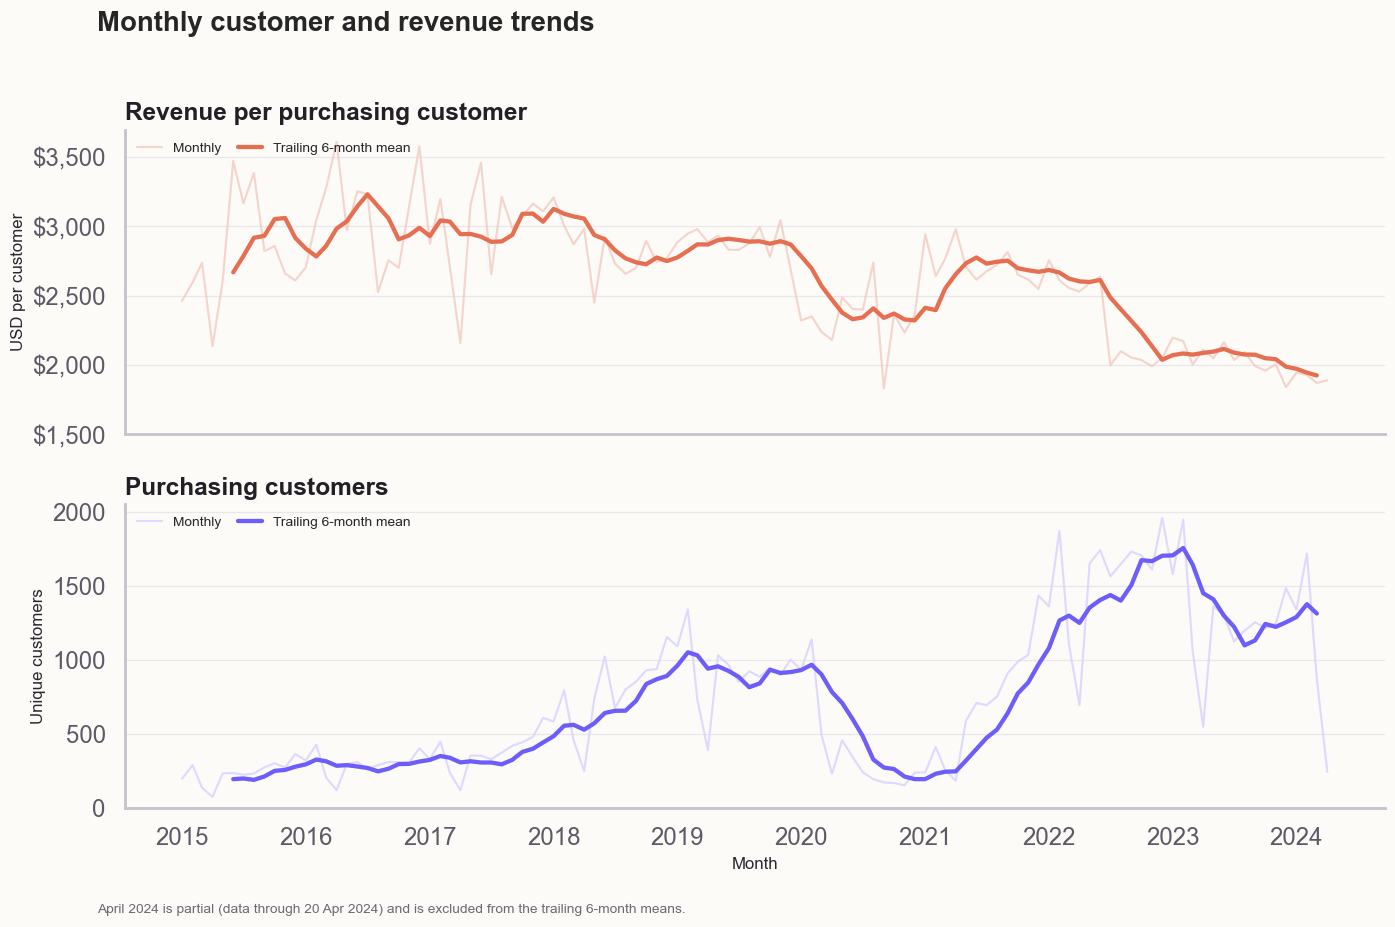

In [3]:
monthly = read_sql_file(engine, "marts/01_monthly_revenue_customer_trends.sql")
monthly["month"] = pd.to_datetime(monthly["month"])

partial_month_start = DATA_CUTOFF.to_period("M").to_timestamp()
has_partial_month = DATA_CUTOFF.day < DATA_CUTOFF.days_in_month
full_month_mask = monthly["month"] < partial_month_start if has_partial_month else pd.Series(True, index=monthly.index)

monthly["customers_6m"] = (
    monthly["unique_customers"]
    .where(full_month_mask)
    .rolling(6, min_periods=6)
    .mean()
)
monthly["avg_rev_6m"] = (
    monthly["avg_revenue_per_customer_usd"]
    .where(full_month_mask)
    .rolling(6, min_periods=6)
    .mean()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

sns.lineplot(
    data=monthly, x="month", y="avg_revenue_per_customer_usd",
    ax=ax1, color=CORAL_LIGHT, alpha=0.75, linewidth=1.4, label="Monthly"
)
sns.lineplot(
    data=monthly, x="month", y="avg_rev_6m",
    ax=ax1, color=CORAL, linewidth=2.8, label="Trailing 6-month mean"
)
ax1.set_title("Revenue per purchasing customer", loc="left")
ax1.set(xlabel="", ylabel="USD per customer")
ax1.set_ylim(bottom=1500)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))
finish_axis(ax1)
ax1.legend(loc="upper left", ncol=2, fontsize=9, handlelength=1.8, columnspacing=1.2)

sns.lineplot(
    data=monthly, x="month", y="unique_customers",
    ax=ax2, color=VIOLET_LIGHT, alpha=0.85, linewidth=1.4, label="Monthly"
)
sns.lineplot(
    data=monthly, x="month", y="customers_6m",
    ax=ax2, color=VIOLET, linewidth=2.8, label="Trailing 6-month mean"
)
ax2.set_title("Purchasing customers", loc="left")
ax2.set(xlabel="Month", ylabel="Unique customers")
ax2.set_ylim(bottom=0)
finish_axis(ax2)
ax2.legend(loc="upper left", ncol=2, fontsize=9, handlelength=1.8, columnspacing=1.2)

fig.suptitle(
    "Monthly customer and revenue trends",
    x=0.08, y=1.01, ha="left", fontsize=18, fontweight="bold"
)
fig.text(
    0.08, -0.015,
    "April 2024 is partial (data through 20 Apr 2024) and is excluded from the trailing 6-month means.",
    ha="left", fontsize=9, color=SUBTEXT
)
fig.tight_layout()
save(fig, "monthly_customer_trend.png")

## 2. Monthly revenue and trailing three-month average

The trailing average is calculated in SQL and uses only the current and prior two months.

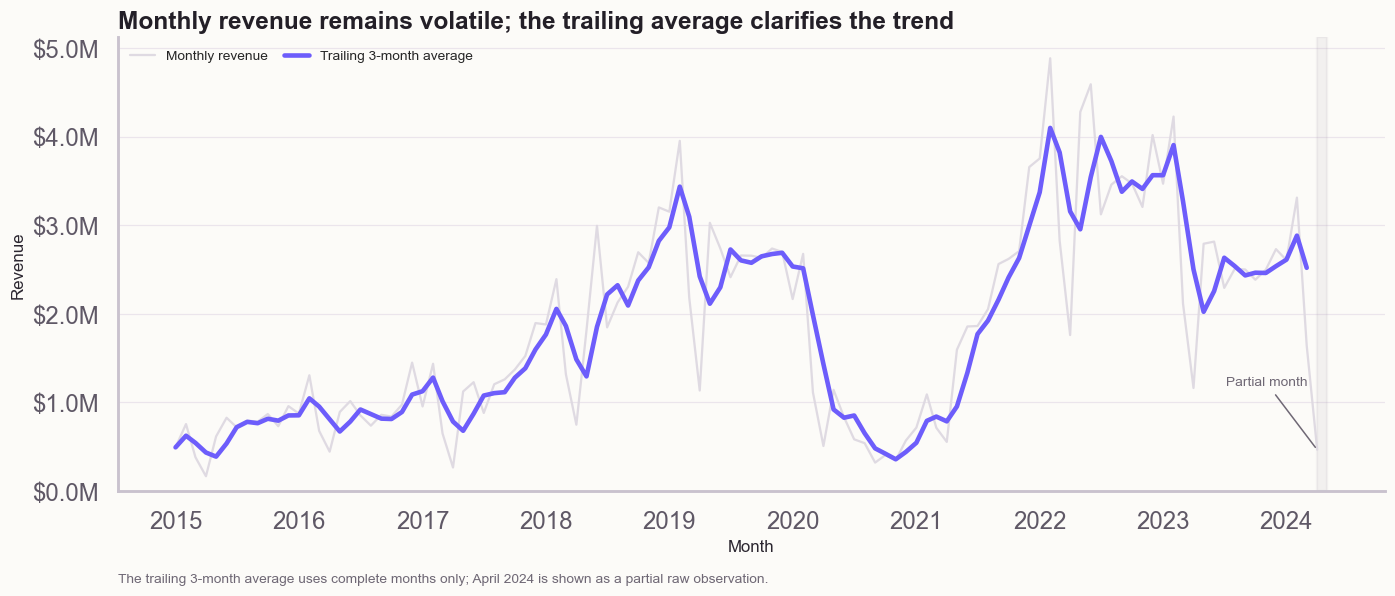

In [4]:
rolling = read_sql_file(engine, "marts/02_three_month_rolling_average.sql")
rolling["month"] = pd.to_datetime(rolling["month"])

partial_month_start = DATA_CUTOFF.to_period("M").to_timestamp()
has_partial_month = DATA_CUTOFF.day < DATA_CUTOFF.days_in_month

rolling["trailing_3m_plot"] = rolling["trailing_3m_avg_revenue_usd"].astype(float)
if has_partial_month:
    rolling.loc[rolling["month"] >= partial_month_start, "trailing_3m_plot"] = np.nan

fig, ax = plt.subplots(figsize=(13, 5.8))

sns.lineplot(
    data=rolling, x="month", y="monthly_revenue_usd",
    ax=ax, color=NEUTRAL_LIGHT, alpha=0.95, linewidth=1.5, label="Monthly revenue"
)
sns.lineplot(
    data=rolling, x="month", y="trailing_3m_plot",
    ax=ax, color=VIOLET, linewidth=3.0, label="Trailing 3-month average"
)

if has_partial_month:
    ax.axvspan(partial_month_start, partial_month_start + pd.offsets.MonthEnd(1), color=NEUTRAL, alpha=0.12)
    partial_row = rolling.loc[rolling["month"] == partial_month_start].iloc[0]
    ax.annotate(
        "Partial month",
        xy=(partial_month_start, partial_row["monthly_revenue_usd"]),
        xytext=(-60, 42), textcoords="offset points",
        arrowprops={"arrowstyle": "-", "color": SUBTEXT, "lw": 1},
        fontsize=9, color=SUBTEXT
    )

ax.set_title("Monthly revenue remains volatile; the trailing average clarifies the trend", loc="left")
ax.set(xlabel="Month", ylabel="Revenue")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(FuncFormatter(usd_millions))
finish_axis(ax)
ax.legend(loc="upper left", ncol=2, fontsize=9, handlelength=1.8, columnspacing=1.2)
add_note(ax, "The trailing 3-month average uses complete months only; April 2024 is shown as a partial raw observation.")
fig.tight_layout()
save(fig, "monthly_revenue_rolling_average.png")

## 3. Observed customer lifetime revenue by value tier

These are descriptive Q1/Q3 tiers of **observed historical customer revenue**

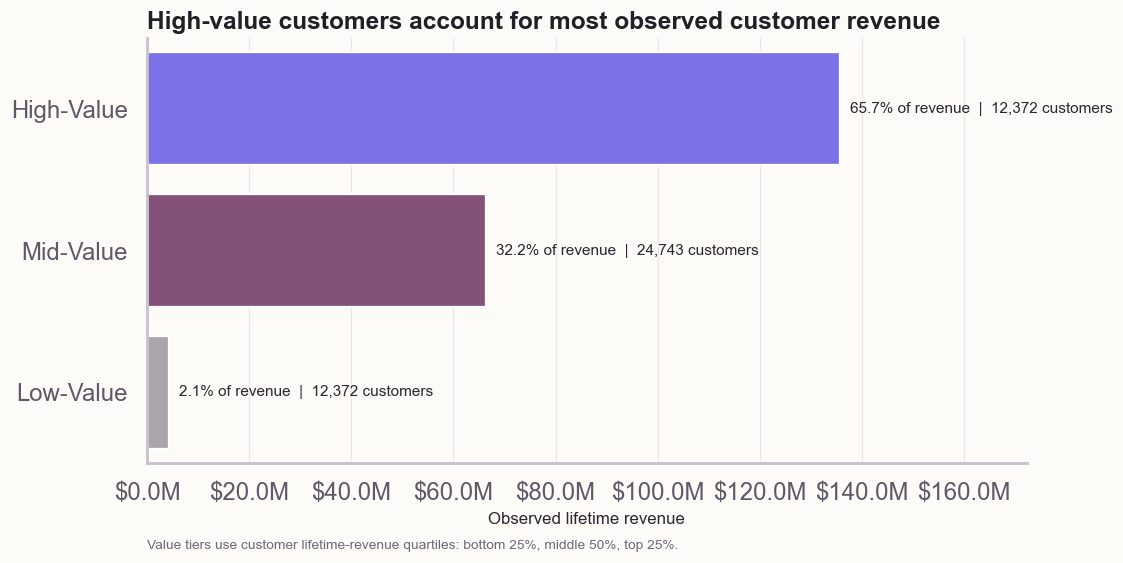

In [5]:
ltv = read_sql_file(engine, "marts/03_customer_lifetime_revenue.sql")

ltv_summary = (
    ltv.groupby("customer_segment", observed=True)
       .agg(
           customers=("customerkey", "count"),
           total_revenue_usd=("lifetime_revenue_usd", "sum"),
           avg_revenue_usd=("lifetime_revenue_usd", "mean"),
       )
       .reset_index()
)
ltv_summary["revenue_share"] = ltv_summary["total_revenue_usd"] / ltv_summary["total_revenue_usd"].sum()
order = ["High-Value", "Mid-Value", "Low-Value"]

fig, ax = plt.subplots(figsize=(10.5, 5.5))
sns.barplot(
    data=ltv_summary,
    y="customer_segment", x="total_revenue_usd",
    order=order, palette={"High-Value": VIOLET, "Mid-Value": PLUM, "Low-Value": NEUTRAL}, hue="customer_segment", legend=False, ax=ax
)

lookup = ltv_summary.set_index("customer_segment")
for i, segment in enumerate(order):
    row = lookup.loc[segment]
    ax.text(
        row["total_revenue_usd"] + ltv_summary["total_revenue_usd"].max() * 0.015,
        i,
        f'{row["revenue_share"]:.1%} of revenue  |  {int(row["customers"]):,} customers',
        va="center", fontsize=10, color=TEXT
    )

ax.set_title("High-value customers account for most observed customer revenue", loc="left")
ax.set(xlabel="Observed lifetime revenue", ylabel="")
ax.xaxis.set_major_formatter(FuncFormatter(usd_millions))
ax.set_xlim(0, ltv_summary["total_revenue_usd"].max() * 1.27)
finish_axis(ax, grid_axis="x")
add_note(ax, "Value tiers use customer lifetime-revenue quartiles: bottom 25%, middle 50%, top 25%.")
fig.tight_layout()
save(fig, "customer_revenue_segments.png")

## 4. Inactivity share by eligible acquisition cohort

Showing percentage rather than stacked counts makes cohorts with different sizes directly comparable.

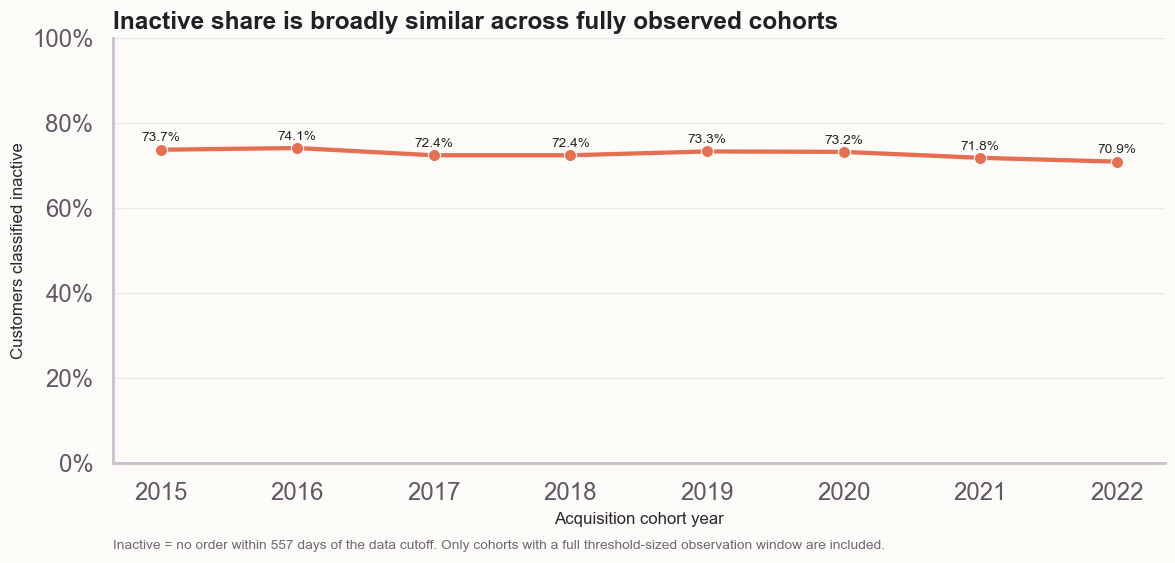

In [6]:
inactive = read_sql_file(engine, "marts/04_customer_inactivity_by_cohort.sql")
inactive_share = inactive.loc[inactive["customer_status"] == "Inactive"].copy()
inactive_share["cohort_year"] = inactive_share["cohort_year"].astype(int)

threshold_days = int(inactive_share["inactivity_threshold_days"].iloc[0])

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.lineplot(
    data=inactive_share,
    x="cohort_year", y="cohort_pct",
    marker="o", markersize=8, linewidth=2.8, color=CORAL, ax=ax
)

for row in inactive_share.itertuples():
    ax.text(row.cohort_year, row.cohort_pct + 2.0, f"{row.cohort_pct:.1f}%", ha="center", fontsize=9)

ax.set_title("Inactive share is broadly similar across fully observed cohorts", loc="left")
ax.set(xlabel="Acquisition cohort year", ylabel="Customers classified inactive")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_ylim(0, 100)
ax.set_xticks(inactive_share["cohort_year"])
finish_axis(ax)
add_note(
    ax,
    f"Inactive = no order within {threshold_days} days of the data cutoff. "
    "Only cohorts with a full threshold-sized observation window are included."
)
fig.tight_layout()
save(fig, "customer_inactivity_by_cohort.png")

## 5. Product category revenue and gross profit

Revenue and gross profit use the same USD scale; gross-margin labels provide the rate context.

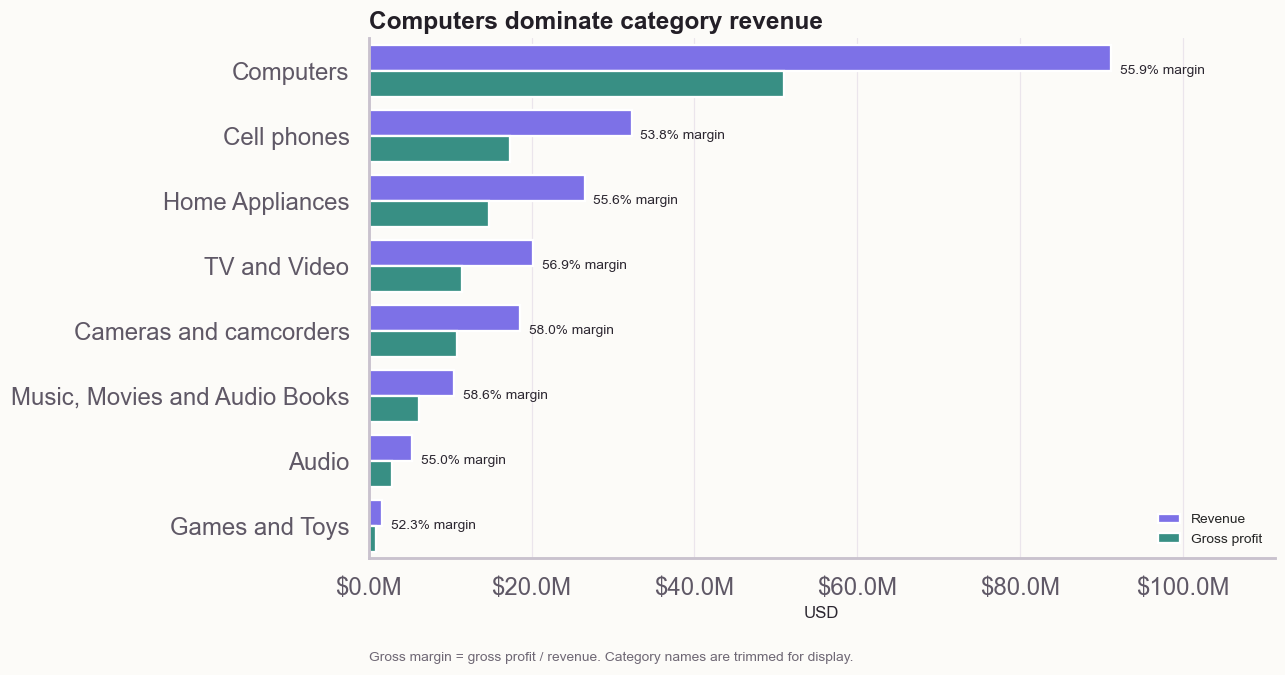

In [7]:
products = read_sql_file(engine, "marts/06_product_analysis.sql").copy()
products["categoryname"] = products["categoryname"].str.strip()
products = products.sort_values("total_revenue_usd", ascending=False)

product_long = products.melt(
    id_vars=["categoryname", "gross_margin_pct"],
    value_vars=["total_revenue_usd", "gross_profit_usd"],
    var_name="metric", value_name="usd"
)
product_long["metric"] = product_long["metric"].map({
    "total_revenue_usd": "Revenue",
    "gross_profit_usd": "Gross profit",
})
order = products["categoryname"].tolist()

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.barplot(
    data=product_long,
    y="categoryname", x="usd", hue="metric",
    order=order, hue_order=["Revenue", "Gross profit"],
    palette={"Revenue": VIOLET, "Gross profit": TEAL},
    errorbar=None, ax=ax
)

margin_lookup = products.set_index("categoryname")["gross_margin_pct"]
revenue_lookup = products.set_index("categoryname")["total_revenue_usd"]
max_revenue = products["total_revenue_usd"].max()
for i, category in enumerate(order):
    ax.text(
        revenue_lookup.loc[category] + max_revenue * 0.012,
        i,
        f"{margin_lookup.loc[category]:.1f}% margin",
        va="center", fontsize=9, color=TEXT
    )

ax.set_title("Computers dominate category revenue", loc="left")
ax.set(xlabel="USD", ylabel="")
ax.xaxis.set_major_formatter(FuncFormatter(usd_millions))
ax.set_xlim(0, max_revenue * 1.22)
finish_axis(ax, grid_axis="x")
ax.legend(title="", loc="lower right", fontsize=9, handlelength=1.6)
add_note(ax, "Gross margin = gross profit / revenue. Category names are trimmed for display.")
fig.tight_layout()
save(fig, "revenue_vs_gross_profit.png")

## 6. Acquisition-month vs returning-customer revenue

The chart highlights the crossover without implying that acquisition activity caused the later returning-customer revenue.

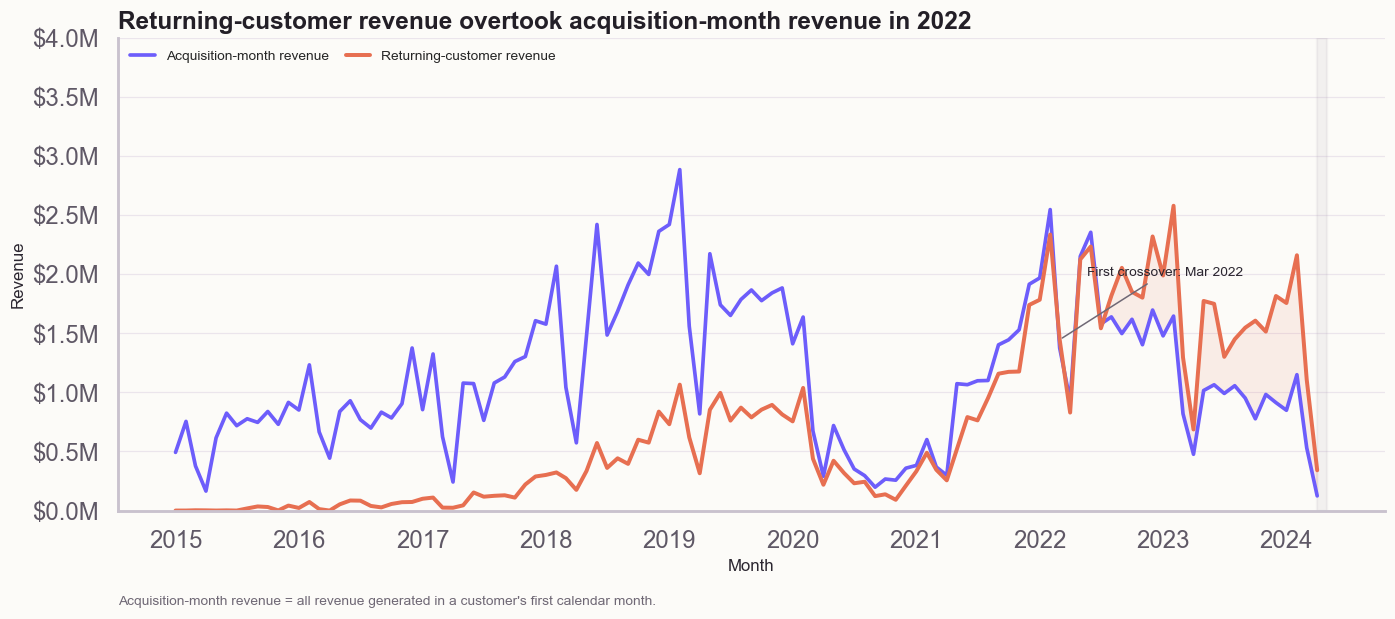

In [11]:
mix = read_sql_file(engine, "marts/07_customer_revenue_mix.sql")
mix["month"] = pd.to_datetime(mix["month"])

fig, ax = plt.subplots(figsize=(13, 6))

sns.lineplot(
    data=mix, x="month", y="acquisition_month_revenue_usd",
    color=VIOLET, linewidth=2.4, label="Acquisition-month revenue", ax=ax
)
sns.lineplot(
    data=mix, x="month", y="returning_customer_revenue_usd",
    color=CORAL, linewidth=2.6, label="Returning-customer revenue", ax=ax
)

ax.fill_between(
    mix["month"],
    mix["acquisition_month_revenue_usd"].astype(float),
    mix["returning_customer_revenue_usd"].astype(float),
    where=(mix["returning_customer_revenue_usd"] >= mix["acquisition_month_revenue_usd"]),
    color=CORAL, alpha=0.10, interpolate=True
)

cross = mix.loc[mix["returning_customer_revenue_usd"] > mix["acquisition_month_revenue_usd"]].iloc[0]
ax.annotate(
    f'First crossover: {cross["month"]:%b %Y}',
    xy=(cross["month"], cross["returning_customer_revenue_usd"]),
    xytext=(18, 42), textcoords="offset points",
    arrowprops={"arrowstyle": "-", "color": SUBTEXT, "lw": 1},
    fontsize=9, color=TEXT
)

partial_month = mix["month"].max()
ax.axvspan(partial_month, partial_month + pd.offsets.MonthEnd(1), color=NEUTRAL, alpha=0.12)

max_monthly_revenue = float(
    mix[["acquisition_month_revenue_usd", "returning_customer_revenue_usd"]].max().max()
)
ax.set_ylim(0, max(4_000_000, max_monthly_revenue * 1.25))

ax.set_title("Returning-customer revenue overtook acquisition-month revenue in 2022", loc="left")
ax.set(xlabel="Month", ylabel="Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(usd_millions))
finish_axis(ax)
ax.legend(loc="upper left", ncol=2, fontsize=9, handlelength=1.8, columnspacing=1.2)
add_note(
    ax,
    "Acquisition-month revenue = all revenue generated in a customer's first calendar month. "
)
fig.tight_layout()
save(fig, "customer_revenue_mix.png")

## 7. RFM segment map — value vs engagement

Bubble size represents the number of customers. Suggested action groups are descriptive portfolio labels, not treatment-effect recommendations.

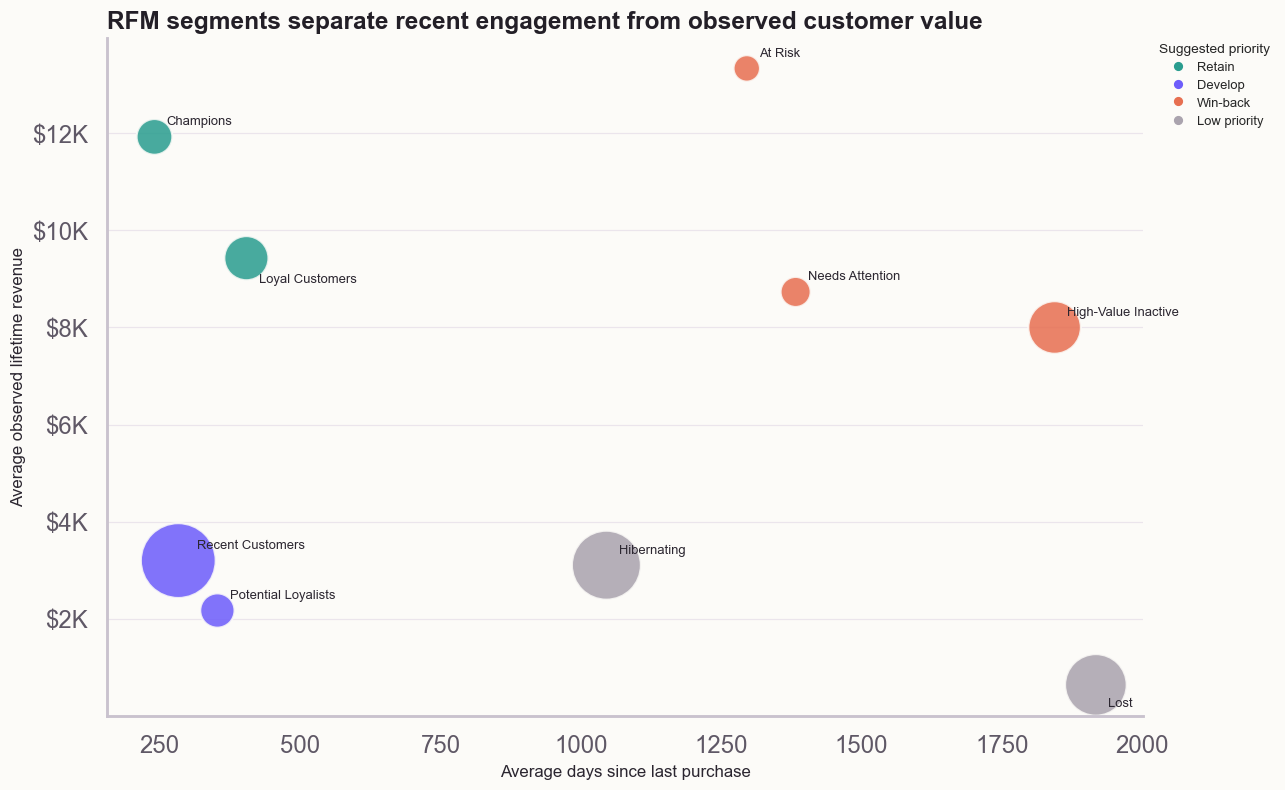

In [12]:
rfm = read_sql_file(engine, "marts/05_rfm_segmentation.sql")

rfm_summary = (
    rfm.groupby("segment")
       .agg(
           customer_count=("customerkey", "count"),
           total_revenue_usd=("monetary_usd", "sum"),
           avg_revenue_usd=("monetary_usd", "mean"),
           avg_days_since_purchase=("days_since_last_purchase", "mean"),
       )
       .reset_index()
)

priority_map = {
    "Champions": "Retain",
    "Loyal Customers": "Retain",
    "Recent Customers": "Develop",
    "Potential Loyalists": "Develop",
    "At Risk": "Win-back",
    "Needs Attention": "Win-back",
    "High-Value Inactive": "Win-back",
    "Hibernating": "Low priority",
    "Lost": "Low priority",
}
rfm_summary["priority"] = rfm_summary["segment"].map(priority_map)

priority_palette = {
    "Retain": TEAL,
    "Develop": VIOLET,
    "Win-back": CORAL,
    "Low priority": NEUTRAL,
}

fig, ax = plt.subplots(figsize=(12, 7.5))
sns.scatterplot(
    data=rfm_summary,
    x="avg_days_since_purchase", y="avg_revenue_usd",
    hue="priority", size="customer_count",
    palette=priority_palette,
    sizes=(300, 2400), alpha=0.86,
    edgecolor=BG, linewidth=1.4,
    legend=False, ax=ax
)

label_offsets = {
    "Champions": (8, 8),
    "Loyal Customers": (8, -16),
    "Recent Customers": (12, 8),
    "Potential Loyalists": (8, 8),
    "At Risk": (8, 8),
    "Needs Attention": (8, 8),
    "High-Value Inactive": (8, 8),
    "Hibernating": (8, 8),
    "Lost": (8, -14),
}
for row in rfm_summary.itertuples():
    dx, dy = label_offsets.get(row.segment, (8, 8))
    ax.annotate(
        row.segment,
        (row.avg_days_since_purchase, row.avg_revenue_usd),
        xytext=(dx, dy), textcoords="offset points",
        fontsize=8.5, color=TEXT
    )

# Compact priority key only. Bubble-size legend is intentionally omitted.
from matplotlib.lines import Line2D
priority_handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=5,
           markerfacecolor=color, markeredgecolor=color, label=label)
    for label, color in priority_palette.items()
]
ax.legend(
    handles=priority_handles,
    title="Suggested priority",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=8.5,
    title_fontsize=9,
    labelspacing=0.45,
    handletextpad=0.5,
)

ax.set_title("RFM segments separate recent engagement from observed customer value", loc="left")
ax.set(xlabel="Average days since last purchase", ylabel="Average observed lifetime revenue")
ax.yaxis.set_major_formatter(FuncFormatter(usd_thousands))
finish_axis(ax)
fig.tight_layout()
save(fig, "rfm_bubble.png")

## 8. Revenue by RFM segment and suggested action group

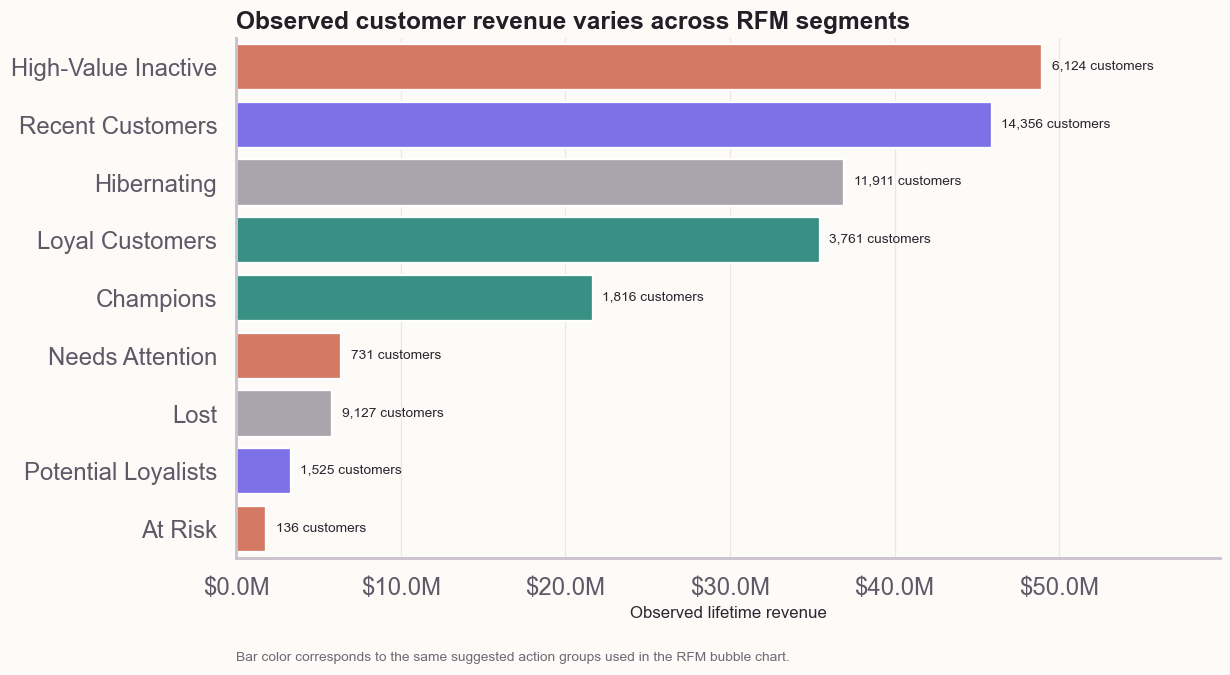

,segment,customer_count,total_revenue_usd,avg_revenue_usd,avg_days_since_purchase,priority
3,High-Value Inactive,"6,124","$48,980,444","$7,998","1,844",Win-back
8,Recent Customers,"14,356","$45,910,334","$3,198",283,Develop
2,Hibernating,"11,911","$36,956,619","$3,103","1,045",Low priority
5,Loyal Customers,"3,761","$35,448,917","$9,425",404,Retain
1,Champions,"1,816","$21,651,800","$11,923",241,Retain
6,Needs Attention,731,"$6,381,464","$8,730","1,383",Win-back
4,Lost,"9,127","$5,821,947",$638,"1,917",Low priority
7,Potential Loyalists,"1,525","$3,308,379","$2,169",353,Develop
0,At Risk,136,"$1,813,244","$13,333","1,296",Win-back


In [10]:
rfm_bar = rfm_summary.sort_values("total_revenue_usd", ascending=False).copy()
segment_palette = {
    row.segment: priority_palette[row.priority]
    for row in rfm_bar.itertuples()
}

fig, ax = plt.subplots(figsize=(11.5, 6.5))
sns.barplot(
    data=rfm_bar,
    y="segment", x="total_revenue_usd",
    order=rfm_bar["segment"].tolist(),
    palette=segment_palette, hue="segment", legend=False,
    ax=ax
)

max_rev = rfm_bar["total_revenue_usd"].max()
for i, row in enumerate(rfm_bar.itertuples()):
    ax.text(
        row.total_revenue_usd + max_rev * 0.012,
        i,
        f"{row.customer_count:,} customers",
        va="center", fontsize=9, color=TEXT
    )

ax.set_title("Observed customer revenue varies across RFM segments", loc="left")
ax.set(xlabel="Observed lifetime revenue", ylabel="")
ax.xaxis.set_major_formatter(FuncFormatter(usd_millions))
ax.set_xlim(0, max_rev * 1.22)
finish_axis(ax, grid_axis="x")
add_note(ax, "Bar color corresponds to the same suggested action groups used in the RFM bubble chart.")
fig.tight_layout()
save(fig, "rfm_revenue_by_segment.png")

display(
    rfm_summary.sort_values("total_revenue_usd", ascending=False)
               .style.format({
                   "customer_count": "{:,.0f}",
                   "total_revenue_usd": "${:,.0f}",
                   "avg_revenue_usd": "${:,.0f}",
                   "avg_days_since_purchase": "{:,.0f}",
               })
)

## QA notes

- All analytical data is loaded from version-controlled SQL mart files through `read_sql_file()`.
- No customer-level SQL is duplicated inside Python.
- Time-series charts explicitly flag the partial April 2024 period.
- RFM revenue is labelled as observed historical revenue, not predictive CLV.
- Inactivity remains a heuristic classification based on the 557-day median observed repeat-order interval.
- The visual system uses a consistent warm editorial palette: violet for the primary series, coral for attention / returning revenue, teal for positive / retain context, and neutral greys for background information.
